<a href="https://colab.research.google.com/github/kuroshkarimi/Machine-Learning-and-Data-Analysis/blob/main/Deep_Learning/Interleaving_Moons.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We have a 2D data from the dataset module of scikitlearn package, forming interleaving moons. there are two features in this dataset along with their classes (either 0 or 1). the data point are not linearly separable.

Use the following three classification model for this dataset with the probability threshold of 0.5:

1. Logistic regression
2. neural network without hidden activations
3. nonlinear ReLU network


In [ ]:
# Importing the required libraries

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
)

# Using the same random seed of data
np.random.seed(42)
tf.random.set_seed(42)



# Creating the dataset
X, y = make_moons(
    n_samples = 4000,
    noise = 0.22,
    random_state = 42

)

print(X.shape)
print(y.shape)
print(np.unique(y, return_counts = True))

(4000, 2)
(4000,)
(array([0, 1]), array([2000, 2000]))


In [ ]:
X, y

(array([[ 0.63664632,  1.26699703],
        [ 1.81815255, -0.24099236],
        [ 0.34405302,  0.7633838 ],
        ...,
        [ 0.13052993,  0.99523752],
        [ 1.63719501, -0.35744641],
        [ 1.04674134, -0.49585629]]),
 array([0, 1, 0, ..., 0, 1, 1]))

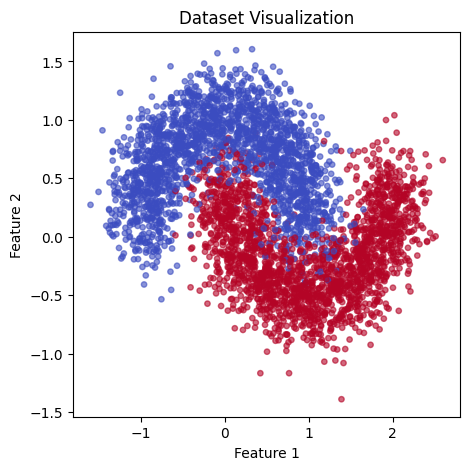

In [ ]:
# Visulalization of the data

plt.figure(figsize = (5, 5))
plt.scatter(X[:, 0], X[:, 1], c = y, cmap = "coolwarm", s = 15, alpha = 0.6)

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Dataset Visualization')
plt.show()

In [ ]:
# Splitting the dataset into train, validation and test parts

X_train, X_TestVal, y_train, y_TestVal = train_test_split(
    X, y, test_size = 0.3, stratify = y, random_state = 42
    )

X_val, X_test, y_val, y_test = train_test_split(
    X_TestVal, y_TestVal, test_size = 0.5, stratify = y_TestVal, random_state = 42
)


In [ ]:
# Standardization of different parts

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


In [ ]:
# 1. Logistic Regression Model

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)
log_reg_proba = log_reg.predict_proba(X_test_scaled)[:, 1]
log_reg_pred = (log_reg_proba > 0.5).astype(int)
print("Prediction, Reality")
comparison = np.hstack((log_reg_pred.reshape(-1, 1), y_test.reshape(-1, 1)))
print(f"\n{comparison}")


Prediction, Reality

[[1 1]
 [1 1]
 [0 0]
 ...
 [0 1]
 [1 0]
 [1 1]]


In [ ]:
# Classification Report

print('classification report\n', classification_report(y_test, log_reg_pred))

classification report
               precision    recall  f1-score   support

           0       0.90      0.85      0.87       300
           1       0.86      0.91      0.88       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600



In [ ]:
# 2. Neural network without hidden activation

# Creating model
nn_wa = Sequential([
    Input(shape = (2,)),
    Dense(16),
    Dense(8),
    Dense(1, activation = 'sigmoid')
])

# Compiling model
nn_wa.compile(
    optimizer = Adam(learning_rate = 1e-3),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

# Fitting model
history_wa = nn_wa.fit(
    X_train_scaled, y_train,
    validation_data = (X_val_scaled, y_val),
    epochs = 100,
    batch_size = 64,
    callbacks = [EarlyStopping(monitor = 'val_loss', patience = 10, restore_best_weights = True)],
    verbose = 1
)



Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6504 - loss: 0.6876 - val_accuracy: 0.7767 - val_loss: 0.5320
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8396 - loss: 0.4396 - val_accuracy: 0.8550 - val_loss: 0.3720
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8650 - loss: 0.3407 - val_accuracy: 0.8667 - val_loss: 0.3208
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8639 - loss: 0.3106 - val_accuracy: 0.8650 - val_loss: 0.3065
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8643 - loss: 0.3019 - val_accuracy: 0.8617 - val_loss: 0.3027
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8654 - loss: 0.2994 - val_accuracy: 0.8650 - val_loss: 0.3018
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8654 - loss: 0.2987 - val_accuracy: 0.8650 - val_loss: 0.3016
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8654 - loss: 0.2986 - val_accuracy: 0.8650

In [ ]:
# Predicting the test section
nn_wa_proba = nn_wa.predict(X_test_scaled)
nn_wa_predict = (nn_wa_proba > 0.5).astype(int)

print('prediction, reality\n')
comparison = np.hstack((nn_wa_predict.reshape(-1, 1), y_test.reshape(-1, 1)))
print(comparison)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
prediction, reality

[[1 1]
 [1 1]
 [0 0]
 ...
 [0 1]
 [1 0]
 [1 1]]


In [ ]:
print(classification_report(y_test, nn_wa_predict))
print('ROC_AUC_SCORE: ', roc_auc_score(y_test, nn_wa_proba))

              precision    recall  f1-score   support

           0       0.90      0.85      0.87       300
           1       0.86      0.91      0.88       300

    accuracy                           0.88       600
   macro avg       0.88      0.88      0.88       600
weighted avg       0.88      0.88      0.88       600

ROC_AUC_SCORE:  0.9619444444444445


In [ ]:
# 3. Nonlinear ReLU network

nn_nl = Sequential([
    Input(shape = (2,)),
    Dense(16, activation = 'relu'),
    Dense(8, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

# Compiling model
nn_nl.compile(
    optimizer = Adam(learning_rate = 1e-3),
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

early_stopping = EarlyStopping(
    monitor =  'val_loss',
    patience = 10,
    restore_best_weights = True
)

# Fitting model

history_nl = nn_nl.fit(
    X_train_scaled, y_train,
    validation_data = (X_val_scaled, y_val),
    epochs = 200,
    batch_size = 64,
    callbacks = [early_stopping],
    verbose = 1
)



Epoch 1/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7364 - loss: 0.6290 - val_accuracy: 0.8350 - val_loss: 0.5504
Epoch 2/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8461 - loss: 0.4988 - val_accuracy: 0.8400 - val_loss: 0.4459
Epoch 3/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8568 - loss: 0.4048 - val_accuracy: 0.8667 - val_loss: 0.3694
Epoch 4/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8611 - loss: 0.3456 - val_accuracy: 0.8650 - val_loss: 0.3310
Epoch 5/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8643 - loss: 0.3188 - val_accuracy: 0.8650 - val_loss: 0.3131
Epoch 6/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8671 - loss: 0.3058 - val_accuracy: 0.8683 - val_loss: 0.3027
Epoch 7/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8704 - loss: 0.2974 - val_accuracy: 0.8767 - val_loss: 0.2947
Epoch 8/200
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8750 - loss: 0.2902 - val_accuracy: 0.880

In [ ]:
# Predicting the test section
nn_nl_proba = nn_nl.predict(X_test_scaled)
nn_nl_predict = (nn_nl_proba > 0.5).astype(int)

print('prediction, reality\n')
comparison = np.hstack((nn_nl_predict.reshape(-1, 1), y_test.reshape(-1, 1)))
print(comparison)

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
prediction, reality

[[1 1]
 [1 1]
 [0 0]
 ...
 [0 1]
 [0 0]
 [1 1]]


In [ ]:
print(classification_report(y_test, nn_nl_predict))
print('ROC AUC SCORE: ', roc_auc_score(y_test, nn_nl_proba))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       300
           1       0.97      0.98      0.97       300

    accuracy                           0.97       600
   macro avg       0.97      0.97      0.97       600
weighted avg       0.97      0.97      0.97       600

ROC AUC SCORE:  0.9972777777777778


In [ ]:
def plot_decision_boundary(
    model,
    X,
    y,
    title,
    is_keras=False,
    threshold=0.5
):
    x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x2_min, x2_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx1, xx2 = np.meshgrid(
        np.linspace(x1_min, x1_max, 400),
        np.linspace(x2_min, x2_max, 400)
    )

    grid = np.column_stack([xx1.ravel(), xx2.ravel()])

    if is_keras:
        probabilities = model.predict(grid, verbose=0).ravel()
    else:
        probabilities = model.predict_proba(grid)[:, 1]

    probabilities = probabilities.reshape(xx1.shape)

    plt.figure(figsize=(7, 5))

    plt.contourf(
        xx1,
        xx2,
        probabilities,
        levels=np.linspace(0, 1, 21),
        cmap="coolwarm",
        alpha=0.35
    )

    plt.contour(
        xx1,
        xx2,
        probabilities,
        levels=[threshold],
        colors="black",
        linewidths=2
    )

    plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap="coolwarm",
        edgecolor="white",
        s=25
    )

    plt.colorbar(label="Predicted probability")
    plt.xlabel("Standardized feature 1")
    plt.ylabel("Standardized feature 2")
    plt.title(title)
    plt.show()

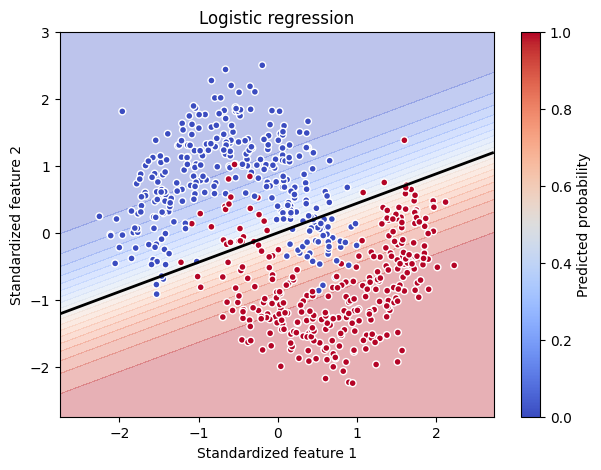

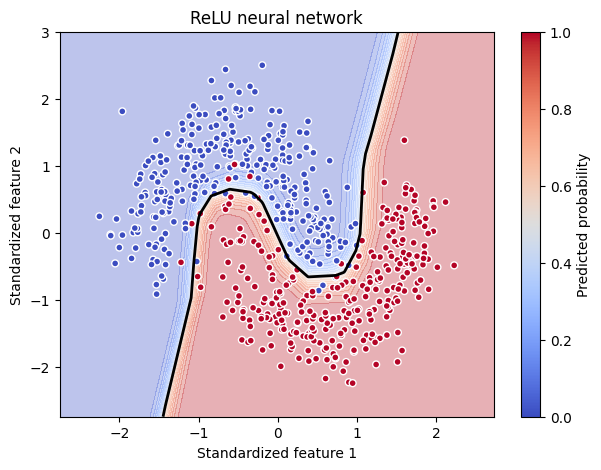

In [ ]:
# Plotting the dicision boundaries along with the data points and predicted probability regions

plot_decision_boundary(
    log_reg,
    X_test_scaled,
    y_test,
    title="Logistic regression",
    is_keras=False
)

plot_decision_boundary(
    nn_nl,
    X_test_scaled,
    y_test,
    title="ReLU neural network",
    is_keras=True
)

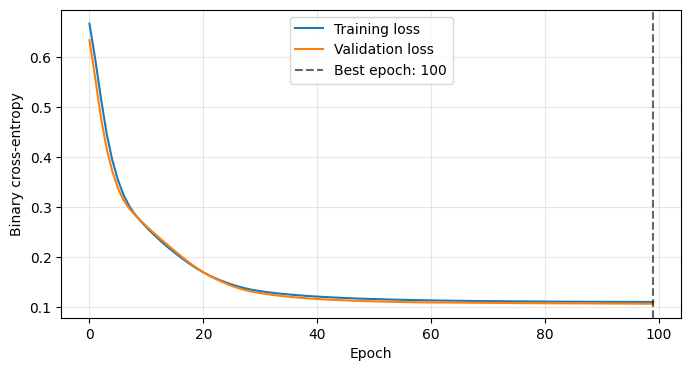

In [ ]:
# Plotting learning curves

plt.figure(figsize=(8, 4))

plt.plot(
    history.history["loss"],
    label="Training loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation loss"
)

best_epoch = np.argmin(history.history["val_loss"])

plt.axvline(
    best_epoch,
    color="black",
    linestyle="--",
    alpha=0.6,
    label=f"Best epoch: {best_epoch + 1}"
)

plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()